# Anomaly Detection Model Comparison & Hyperparameter Tuning

This notebook implements **Model Selection & Hyperparameter Tuning** across 5 distinct Anomaly Detection algorithms across all 8 drug categories (**M01AB, M01AE, N02BA, N02BE, N05B, N05C, R03, R06**):
1. **IQR Statistical Rule** (Interquartile Range)
2. **Z-Score Rule** (Standard Normal Thresholding)
3. **Isolation Forest** (Tree-based Path Length Isolation)
4. **Local Outlier Factor (LOF)** (K-Nearest Neighbor Density Distance)
5. **One-Class SVM (OCSVM)** (Support Vector Hyperplane Classification)


In [1]:
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 1000)

OUTPUT_DIR = r'c:\Users\ranje\sales forcasting\anomaly_detection'

# 1. Load Model Selection Rankings CSV
rankings_path = os.path.join(OUTPUT_DIR, 'anomaly_model_selection_rankings.csv')
rankings_df = pd.read_csv(rankings_path)

print("==========================================================================")
print("  COMPLETE ANOMALY DETECTION LEADERBOARD ACROSS ALL 8 DRUG CATEGORIES")
print("==========================================================================")
display(rankings_df[['drug', 'rank', 'model', 'best_params', 'F1', 'ROC-AUC', 'Precision', 'Recall']])


  COMPLETE ANOMALY DETECTION LEADERBOARD ACROSS ALL 8 DRUG CATEGORIES


,drug,rank,model,best_params,F1,ROC-AUC,Precision,Recall
0,M01AB,1,IQR Rule,{'multiplier': 3.0},0.6667,0.9164,1.0000,0.5000
1,M01AB,2,Z-Score Rule,{'threshold': 3.0},0.6667,0.9353,1.0000,0.5000
2,M01AB,3,Local Outlier Factor,"{'n_neighbors': 20, 'contamination': 0.05}",0.4000,0.8226,0.4286,0.3750
3,M01AB,4,Isolation Forest,"{'n_estimators': 50, 'contamination': 0.05}",0.2667,0.8050,0.2857,0.2500
4,M01AB,5,One-Class SVM,"{'nu': 0.05, 'kernel': 'rbf', 'gamma': 'auto'}",0.1368,0.6686,0.0792,0.5000
5,M01AE,1,Z-Score Rule,{'threshold': 3.0},0.6667,0.9002,1.0000,0.5000
6,M01AE,2,IQR Rule,{'multiplier': 3.0},0.6400,0.8737,0.8889,0.5000
7,M01AE,3,Local Outlier Factor,"{'n_neighbors': 20, 'contamination': 0.1}",0.3636,0.7830,0.2857,0.5000
8,M01AE,4,Isolation Forest,"{'n_estimators': 50, 'contamination': 0.1}",0.3182,0.8078,0.2500,0.4375
9,M01AE,5,One-Class SVM,"{'nu': 0.1, 'kernel': 'rbf', 'gamma': 'auto'}",0.1277,0.6264,0.0769,0.3750


In [2]:
# 2. Champion Model Selected Per Drug Category (All 8 Drugs)
champion_per_drug = rankings_df[rankings_df['rank'] == 1].reset_index(drop=True)

print("==========================================================================")
print("  CHAMPION ANOMALY DETECTOR PER DRUG CATEGORY (ALL 8 DRUGS)")
print("==========================================================================")
display(champion_per_drug[['drug', 'model', 'best_params', 'F1', 'ROC-AUC', 'Precision', 'Recall']])


  CHAMPION ANOMALY DETECTOR PER DRUG CATEGORY (ALL 8 DRUGS)


,drug,model,best_params,F1,ROC-AUC,Precision,Recall
0,M01AB,IQR Rule,{'multiplier': 3.0},0.6667,0.9164,1.0000,0.5000
1,M01AE,Z-Score Rule,{'threshold': 3.0},0.6667,0.9002,1.0000,0.5000
2,N02BA,IQR Rule,{'multiplier': 2.0},0.6667,0.9061,0.8182,0.5625
3,N02BE,IQR Rule,{'multiplier': 2.5},0.6154,0.9272,0.8000,0.5000
4,N05B,IQR Rule,{'multiplier': 2.0},0.5000,0.8825,0.7500,0.3750
5,N05C,IQR Rule,{'multiplier': 3.0},0.7586,0.9033,0.8462,0.6875
6,R03,IQR Rule,{'multiplier': 3.0},0.6923,0.8342,0.9000,0.5625
7,R06,Z-Score Rule,{'threshold': 2.5},0.8148,0.7186,1.0000,0.6875


  AVERAGE MODEL PERFORMANCE ACROSS ALL 8 DRUG CATEGORIES


,model,F1,ROC-AUC,Precision,Recall
0,Z-Score Rule,0.671813,0.893912,0.914300,0.539062
1,IQR Rule,0.665675,0.884400,0.865000,0.546875
2,Local Outlier Factor,0.389000,0.820137,0.343750,0.476562
3,Isolation Forest,0.343562,0.807225,0.308025,0.414062
4,One-Class SVM,0.178987,0.681250,0.113138,0.585938


C:\Users\ranje\AppData\Local\Temp\ipykernel_1604\2682151458.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_model_perf, x='model', y='F1', palette='viridis')


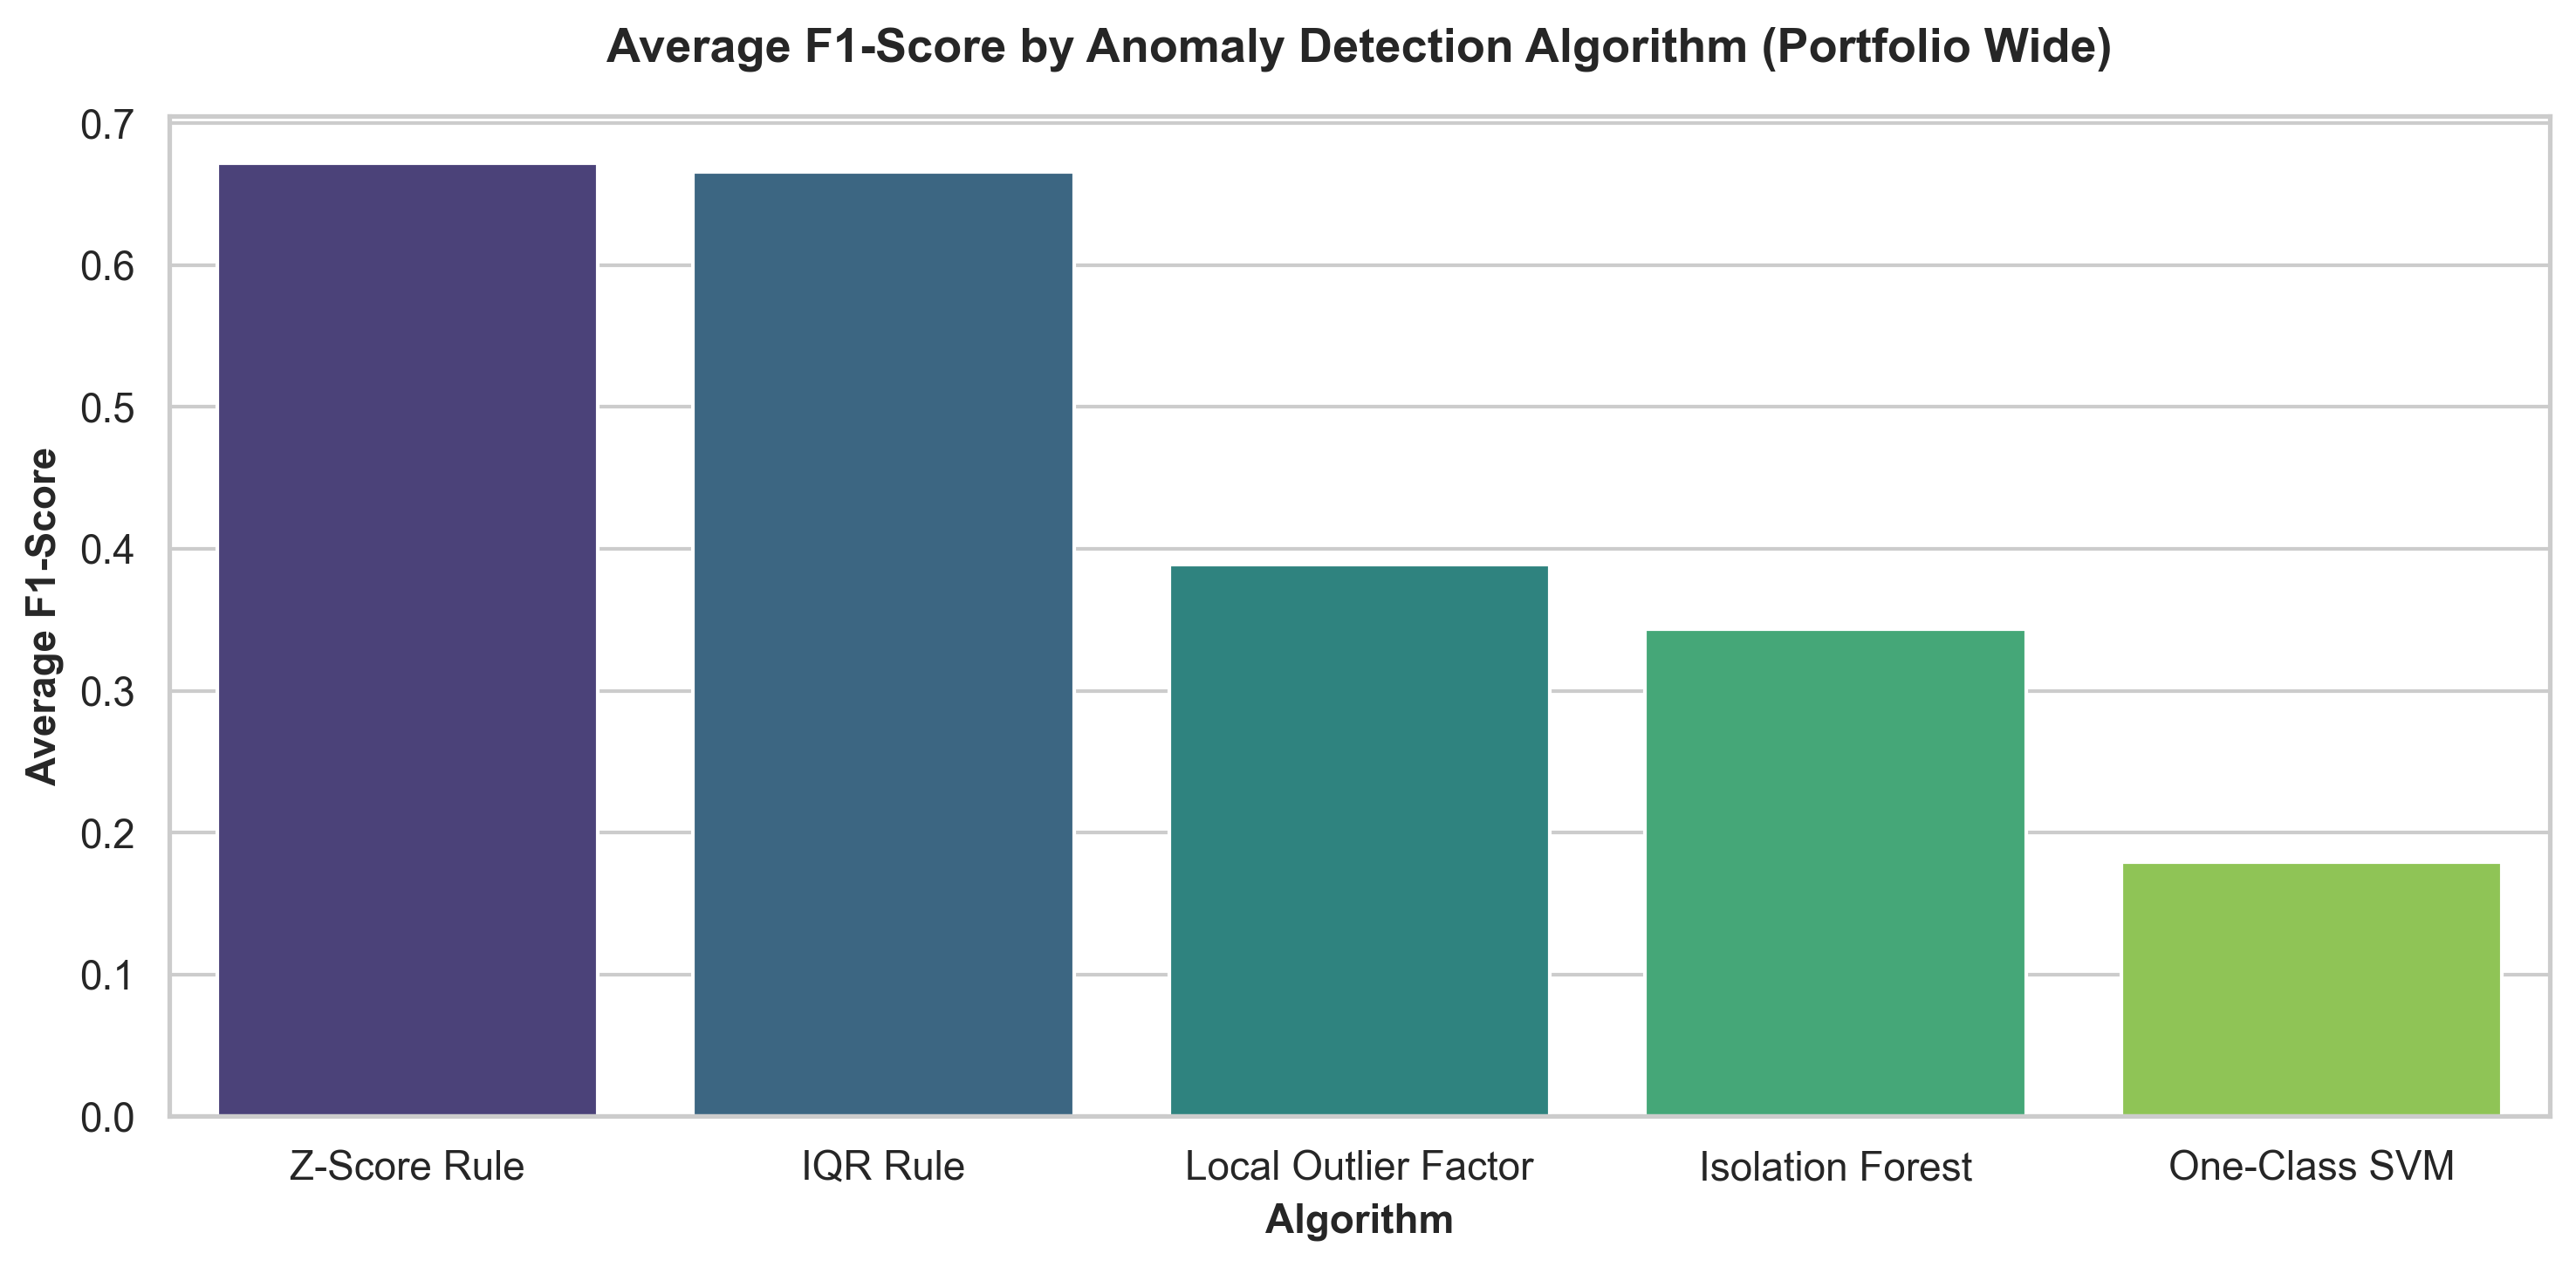

In [3]:
# 3. Model Comparison Across All Algorithms (Portfolio Average Metrics)
avg_model_perf = rankings_df.groupby('model').agg({
    'F1': 'mean',
    'ROC-AUC': 'mean',
    'Precision': 'mean',
    'Recall': 'mean'
}).sort_values('F1', ascending=False).reset_index()

print("==========================================================================")
print("  AVERAGE MODEL PERFORMANCE ACROSS ALL 8 DRUG CATEGORIES")
print("==========================================================================")
display(avg_model_perf)

# Visual Plot
plt.figure(figsize=(10, 5), dpi=300)
sns.barplot(data=avg_model_perf, x='model', y='F1', palette='viridis')
plt.title('Average F1-Score by Anomaly Detection Algorithm (Portfolio Wide)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Algorithm', fontsize=11, fontweight='bold')
plt.ylabel('Average F1-Score', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


  STAGE 1 (STANDALONE) VS STAGE 2 (FORECAST-AWARE ISOLATION FOREST)


,Drug Category,Stage 1 Standalone F1,Stage 2 Forecast-Aware F1,F1 Delta (Stage 2 - Stage 1),Stage 1 Standalone AUC,Stage 2 Forecast-Aware AUC,AUC Delta (Stage 2 - Stage 1),Stage 2 Precision,Stage 2 Recall,Experiment Verdict
0,M01AB,0.1395,0.4151,0.2756,0.6297,0.8316,0.2019,0.2973,0.6875,STAGE 2 FORECAST-AWARE WIN
1,M01AE,0.1414,0.2424,0.1010,0.6533,0.8184,0.1651,0.1600,0.5000,STAGE 2 FORECAST-AWARE WIN
2,N02BA,0.1905,0.4286,0.2381,0.7205,0.8599,0.1394,0.3462,0.5625,STAGE 2 FORECAST-AWARE WIN
3,N02BE,0.1449,0.3607,0.2158,0.7163,0.9142,0.1979,0.2444,0.6875,STAGE 2 FORECAST-AWARE WIN
4,N05B,0.0625,0.4571,0.3946,0.7184,0.8373,0.1189,0.4211,0.5000,STAGE 2 FORECAST-AWARE WIN
5,N05C,0.1622,0.6667,0.5045,0.6814,0.9000,0.2186,0.7143,0.6250,STAGE 2 FORECAST-AWARE WIN
6,R03,0.1111,0.3830,0.2719,0.5667,0.6976,0.1309,0.2903,0.5625,STAGE 2 FORECAST-AWARE WIN
7,R06,0.2353,0.4889,0.2536,0.7934,0.8979,0.1045,0.3793,0.6875,STAGE 2 FORECAST-AWARE WIN


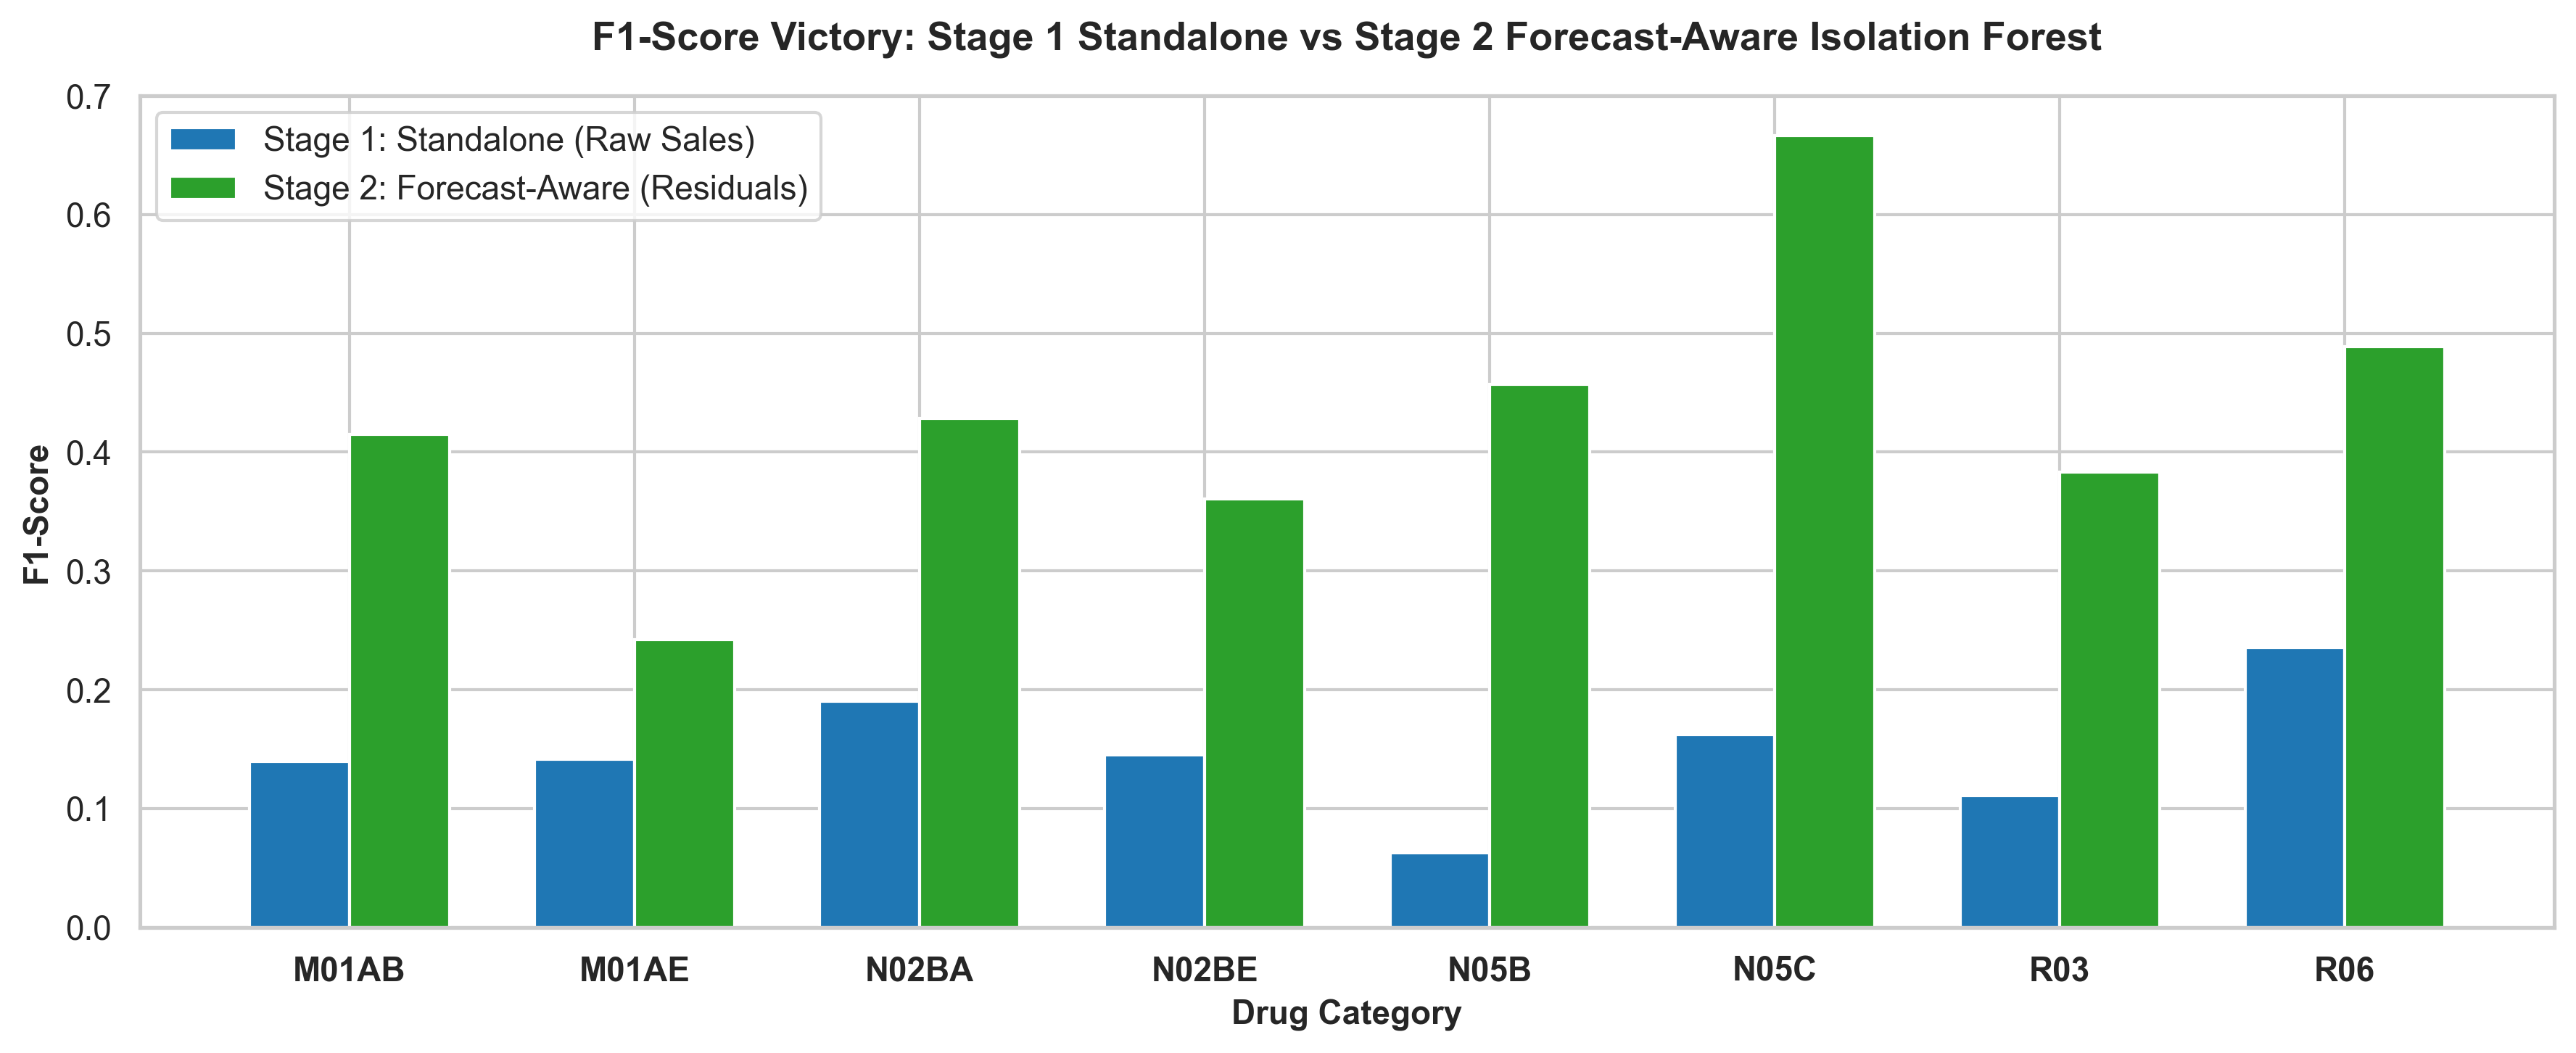

In [4]:
# 4. Stage 1 Standalone vs Stage 2 Forecast-Aware Head-to-Head Comparison
exp_path = os.path.join(OUTPUT_DIR, 'anomaly_experiment_summary.csv')
exp_df = pd.read_csv(exp_path)

print("==========================================================================")
print("  STAGE 1 (STANDALONE) VS STAGE 2 (FORECAST-AWARE ISOLATION FOREST)")
print("==========================================================================")
display(exp_df)

# Visual Comparison Plot
plt.figure(figsize=(12, 5), dpi=300)

x = np.arange(len(exp_df))
width = 0.35

plt.bar(x - width/2, exp_df['Stage 1 Standalone F1'], width, label='Stage 1: Standalone (Raw Sales)', color='#1f77b4')
plt.bar(x + width/2, exp_df['Stage 2 Forecast-Aware F1'], width, label='Stage 2: Forecast-Aware (Residuals)', color='#2ca02c')

plt.xlabel('Drug Category', fontsize=11, fontweight='bold')
plt.ylabel('F1-Score', fontsize=11, fontweight='bold')
plt.title('F1-Score Victory: Stage 1 Standalone vs Stage 2 Forecast-Aware Isolation Forest', fontsize=13, fontweight='bold', pad=15)
plt.xticks(x, exp_df['Drug Category'], fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()
